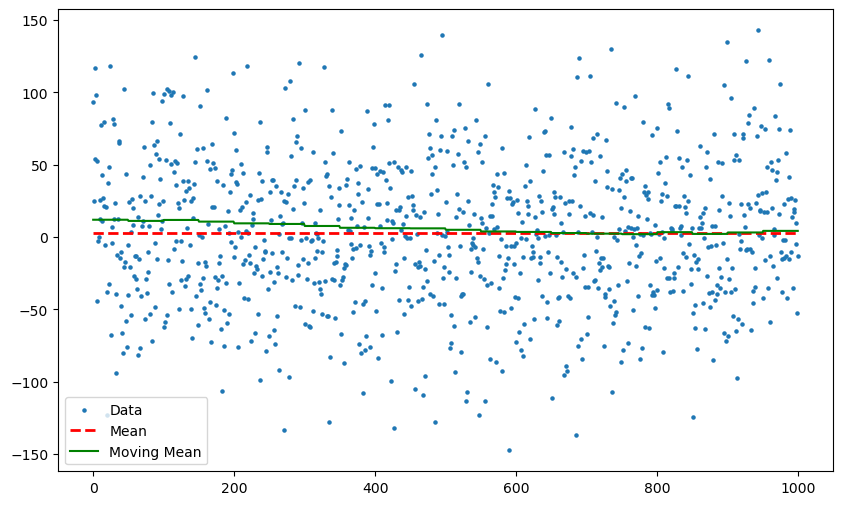

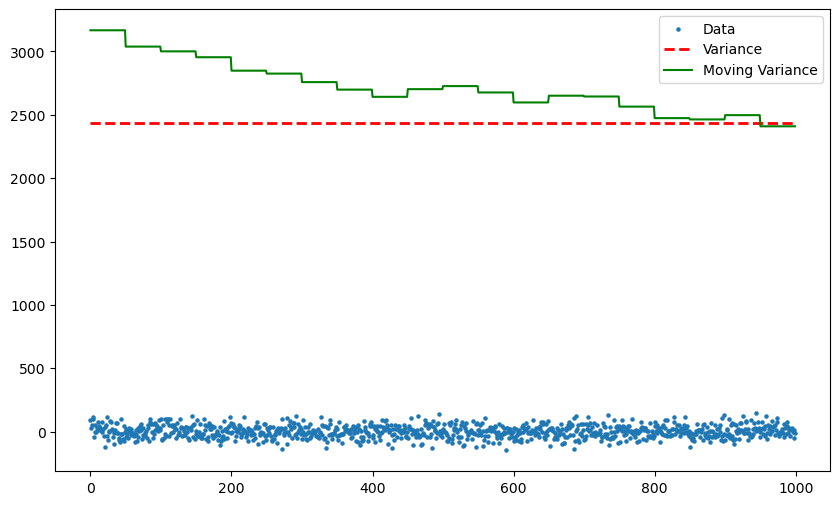

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def moving_average(data, moving_mean, momentum=0.9):
    data_mean = np.mean(data)
    moving_mean = momentum * moving_mean + (1 - momentum) * data_mean
    return moving_mean

def moving_variance_call(data, moving_variance, momentum=0.9):
    data_variance = np.var(data)
    moving_variance = momentum * moving_variance + (1 - momentum) * data_variance
    return moving_variance

# 生成随机序列
np.random.seed(0)
# data = np.random.randn(1000)
# data = np.array(range(1000))
data = np.random.normal(5, 50, 1000)

# 计算均值
mean = np.mean(data)

# 计算移动平均值
moving_window = 50
moving_mean = np.zeros(len(data))
for i in range(len(data)//moving_window):
    moving_mean[i*moving_window:(i+1)*moving_window] = moving_average(data[i*moving_window:(i+1)*moving_window], 
                                                                      moving_mean[i*moving_window-1] if i > 0 else np.mean(data[:moving_window]), 
                                                                      0.9)


# 绘制图表
plt.figure(figsize=(10, 6))
# plt.plot(data, label='Data')
scatter_size = 5000//len(data)
plt.scatter(range(len(data)), data, label='Data', s=scatter_size)
plt.plot([mean]*len(data), 'r--', label='Mean', linewidth=2)
plt.plot(moving_mean, 'g-', label='Moving Mean')
plt.legend()
plt.show()

# 计算方差
variance = np.var(data)

# 计算移动方差
moving_variance = np.zeros(len(data))
for i in range(len(data)//moving_window):
    moving_variance[i*moving_window:(i+1)*moving_window] = moving_variance_call(data[i*moving_window:(i+1)*moving_window], 
                                                                          moving_variance[i*moving_window-1] if i > 0 else np.var(data[:moving_window]), 
                                                                          0.9)
    
# 绘制图表
plt.figure(figsize=(10, 6))
# plt.plot(data, label='Data')
plt.scatter(range(len(data)), data, label='Data', s=scatter_size)
plt.plot([variance]*len(data), 'r--', label='Variance', linewidth=2)
plt.plot(moving_variance, 'g-', label='Moving Variance')
plt.legend()
plt.show()
